In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('../../../Data/train.csv',usecols=['Age','Fare','Survived'])

In [15]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [16]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [17]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [20]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [21]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [22]:
train_age_null = X_train['Age_imputed'].isnull()
test_age_null = X_test['Age_imputed'].isnull()

X_train.loc[train_age_null, 'Age_imputed'] = X_train['Age'].dropna().sample(train_age_null.sum()).values
X_test.loc[test_age_null, 'Age_imputed'] = X_train['Age'].dropna().sample(test_age_null.sum()).values

In [23]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([16.  , 15.  , 20.  , 36.  , 25.  , 16.  , 43.  , 25.  , 49.  ,
       19.  , 23.  , 57.  , 29.  , 22.  , 21.  , 43.  ,  8.  , 40.  ,
       25.  , 31.  , 22.  , 30.  , 19.  , 64.  , 48.  , 62.  , 30.  ,
       30.  , 30.  , 28.  , 25.  , 29.  , 22.  , 22.  , 41.  , 19.  ,
       34.  , 32.  , 43.  , 48.  , 24.  , 33.  , 26.  , 15.  , 71.  ,
       32.5 , 27.  , 58.  , 24.  ,  5.  , 49.  , 18.  , 13.  , 21.  ,
       27.  , 29.  ,  4.  , 18.  , 32.  , 27.  , 47.  , 22.  , 39.  ,
       33.  , 36.  , 29.  , 49.  , 29.  , 28.5 , 48.  , 44.  , 20.  ,
       35.  , 40.  , 28.  , 22.  , 51.  , 32.  ,  0.83, 30.  , 20.  ,
       38.  , 40.  , 34.  , 22.  , 28.  , 45.  , 36.  , 35.  , 19.  ,
       30.  , 50.  ,  1.  , 38.  , 25.  , 21.  ,  7.  , 31.  , 24.  ,
       24.  , 27.  , 63.  , 45.  , 33.  , 24.  , 47.  , 21.  , 17.  ,
       44.  , 34.  ,  9.  , 20.  , 42.  , 38.  , 38.  , 28.  ,  2.  ,
       45.  , 29.  , 24.  , 46.  , 16.  , 22.  , 18.  , 14.  , 18.  ,
       20.  , 19.  ,

In [24]:
X_train['Age'].isnull().sum()

np.int64(148)

In [25]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,35.0
493,71.0,49.5042,71.0
527,NaN,221.7792,2.0


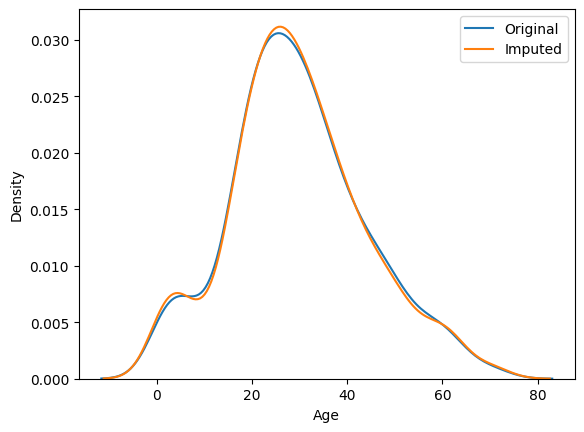

In [28]:
sns.kdeplot(X_train['Age'].dropna(), label='Original')
sns.kdeplot(X_train['Age_imputed'].dropna(), label='Imputed')

plt.legend()
plt.show()

In [29]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  206.13529892934466


In [30]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,56.602324
Age,71.512440,204.349513,204.349513
Age_imputed,56.602324,204.349513,206.135299


<Axes: >

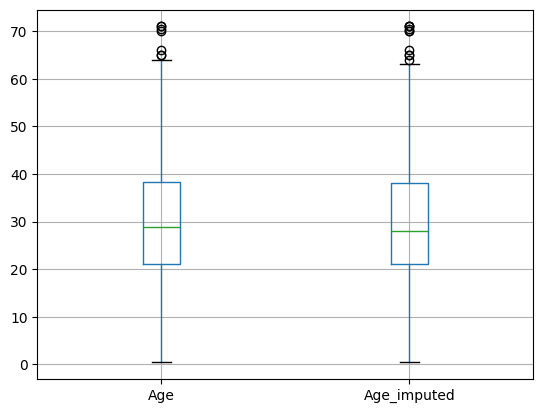

In [31]:
X_train[['Age', 'Age_imputed']].boxplot()

### Categorical data